# Sección 1 Entendimiento del negocio

### Contexto del Proyecto

El Banco Charizard está enfocado en reducir los riesgos asociados a la concesión de créditos, especialmente a clientes con un alto perfil de riesgo. Actualmente, la identificación de estos clientes se basa en métodos tradicionales que resultan ineficientes y no siempre precisos.

### Objetivo del Proyecto

El objetivo principal de este proyecto es utilizar datos históricos de créditos concedidos para comprender mejor los factores que contribuyen al riesgo crediticio. A partir de este análisis, se preparará un modelo de Inteligencia Artificial capaz de clasificar a los clientes en función de su riesgo (`Risk`), categorizado como 'good' (bajo riesgo) o 'bad' (alto riesgo), con el fin de optimizar las decisiones de aprobación de créditos y minimizar las pérdidas financieras del banco.

In [ ]:
# Importamos librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carga de datos desde el archivo CSV
df = pd.read_csv("german_credit_data.csv")

In [ ]:
# Muestra las primeras 5 filas del DataFrame
print("Primeras 5 filas del DataFrame:")
display(df.head())

Primeras 5 filas del DataFrame:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
# Información general del DataFrame, incluyendo tipos de datos y valores no nulos
print("Información del DataFrame (df.info()):")
df.info()

Información del DataFrame (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
# Descripción estadística de las variables numéricas
print("Descripción estadística de las variables numéricas")
display(df.describe())

Descripción estadística de las variables numéricas (df.describe()):


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


# Sección 2 EDA

## Preguntas orientadoras
- ¿Qué variables tiene el dataset?  
- ¿Cómo se relaciona el propósito del crédito con el estado del deudor?  
- ¿Cómo se relaciona la cuenta bancaria con el estado del deudor? (tomando en cuenta checking y saving accounts)


### 1. Resumen de Variables

In [ ]:
# Muestra los tipos de datos de cada columna
print("Tipos de datos de las columnas:")
display(df.dtypes)

# Identifica columnas numéricas y categóricas
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\nColumnas Numéricas: {numerical_cols}")
print(f"Columnas Categóricas: {categorical_cols}")

Tipos de datos de las columnas:


,0
Unnamed: 0,int64
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object



Columnas Numéricas: ['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration']
Columnas Categóricas: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']


### 2. Estadísticas Descriptivas para Variables Numéricas

In [ ]:
# Estadísticas descriptivas de las columnas numéricas relevantes
print("Estadísticas descriptivas para Age, Credit amount, Duration:")
display(df[['Age', 'Credit amount', 'Duration']].describe().T)

Estadísticas descriptivas para Age, Credit amount, Duration:


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


### 3. Tablas de Frecuencia para Variables Categóricas

In [ ]:
# Tablas de frecuencia para variables categóricas seleccionadas
print("\nFrecuencia de Sex:")
display(df['Sex'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nFrecuencia de Housing:")
display(df['Housing'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nFrecuencia de Purpose:")
display(df['Purpose'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nFrecuencia de Saving accounts:")
display(df['Saving accounts'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nFrecuencia de Checking account:")
display(df['Checking account'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nFrecuencia de Risk:")
display(df['Risk'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Frecuencia de Sex:


,proportion
Sex,
male,69.0%
female,31.0%



Frecuencia de Housing:


,proportion
Housing,
own,71.3%
rent,17.9%
free,10.8%



Frecuencia de Purpose:


...

,proportion
Saving accounts,
little,73.81%
moderate,12.61%
quite rich,7.71%
rich,5.88%



Frecuencia de Checking account:


,proportion
Checking account,
little,45.21%
moderate,44.39%
rich,10.4%



Frecuencia de Risk:


,proportion
Risk,
good,70.0%
bad,30.0%


### 4. Valores Faltantes

In [ ]:
# Conteo de valores nulos por columna
print("\nConteo de valores nulos por columna:")
missing_values = df.isnull().sum()
missing_values_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_values_percent})
display(missing_df[missing_df['Missing Count'] > 0])


Conteo de valores nulos por columna:


,Missing Count,Missing Percentage
Saving accounts,183,18.3
Checking account,394,39.4


### 5. Visualizaciones

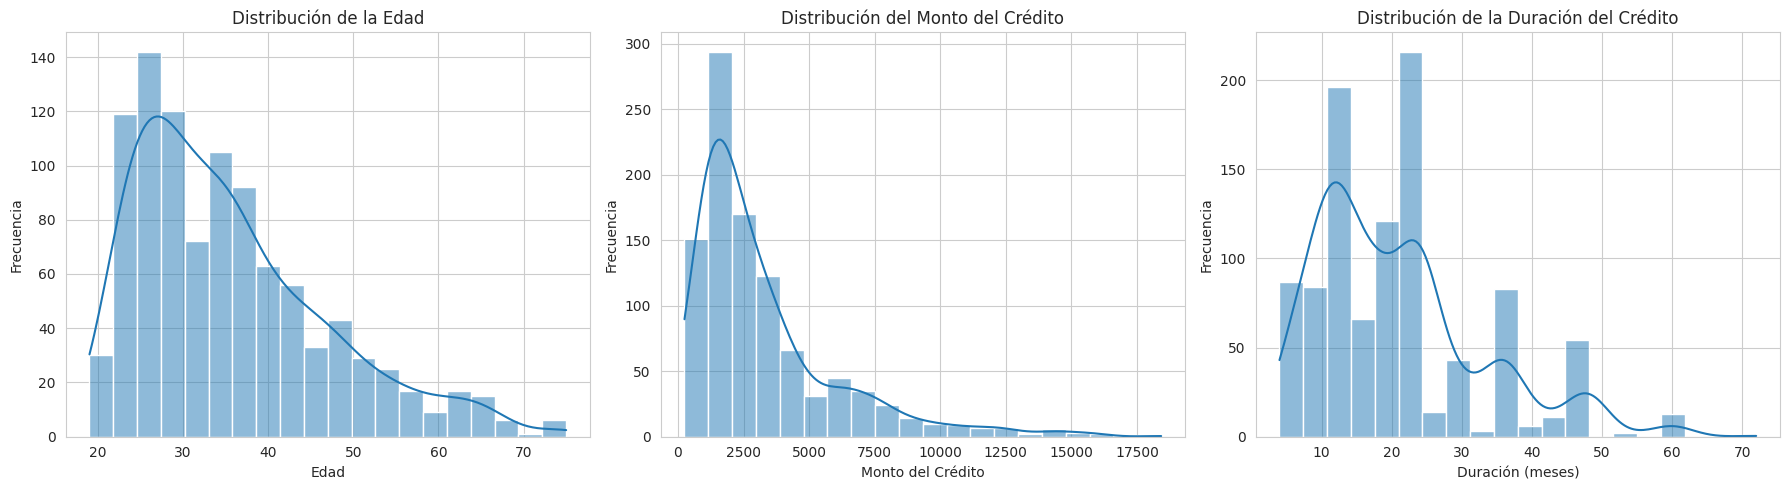

In [ ]:
plt.figure(figsize=(18, 5))

# Histograma de Age
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Distribución de la Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Histograma de Credit amount
plt.subplot(1, 3, 2)
sns.histplot(df['Credit amount'], kde=True, bins=20)
plt.title('Distribución del Monto del Crédito')
plt.xlabel('Monto del Crédito')
plt.ylabel('Frecuencia')

# Histograma de Duration
plt.subplot(1, 3, 3)
sns.histplot(df['Duration'], kde=True, bins=20)
plt.title('Distribución de la Duración del Crédito')
plt.xlabel('Duración (meses)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

/tmp/ipython-input-2164442575.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk', data=df, palette='viridis')


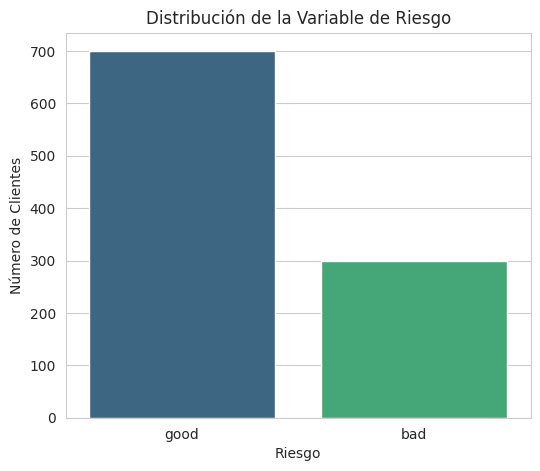

In [ ]:
# Gráfico de barras de la distribución de Risk (good/bad)
plt.figure(figsize=(6, 5))
sns.countplot(x='Risk', data=df, palette='viridis')
plt.title('Distribución de la Variable de Riesgo')
plt.xlabel('Riesgo')
plt.ylabel('Número de Clientes')
plt.show()

/tmp/ipython-input-1143800077.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_by_purpose.index, y=risk_by_purpose.values, palette='plasma')


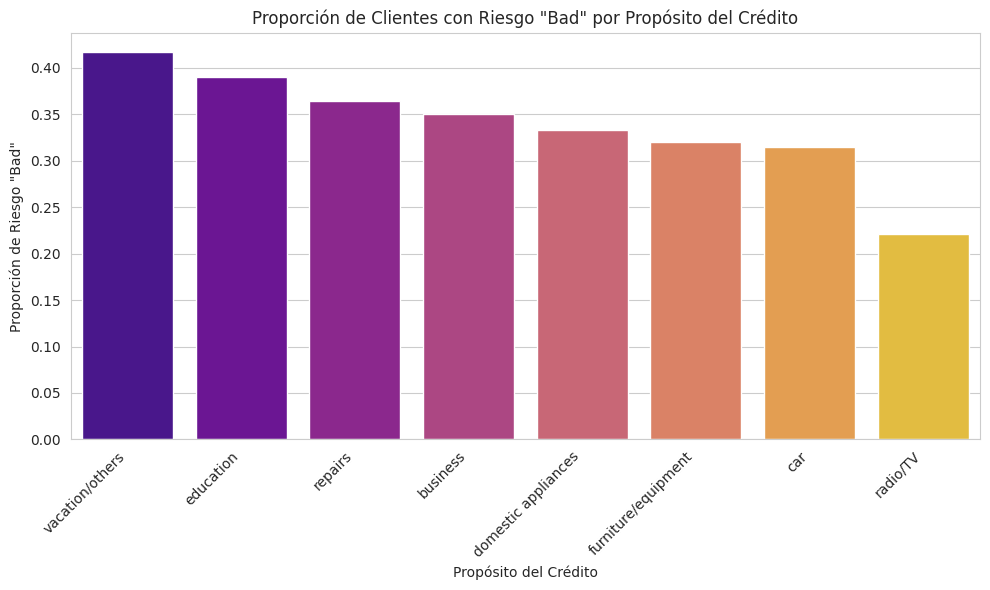

In [ ]:
# Mapear 'Risk' a valores numéricos para calcular proporciones
df['Risk_encoded'] = df['Risk'].apply(lambda x: 1 if x == 'bad' else 0)

# Gráfico de barras con proporción de clientes 'bad' por Purpose
plt.figure(figsize=(10, 6))
risk_by_purpose = df.groupby('Purpose')['Risk_encoded'].mean().sort_values(ascending=False)
sns.barplot(x=risk_by_purpose.index, y=risk_by_purpose.values, palette='plasma')
plt.title('Proporción de Clientes con Riesgo "Bad" por Propósito del Crédito')
plt.xlabel('Propósito del Crédito')
plt.ylabel('Proporción de Riesgo "Bad"')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-652777787.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_by_checking_account.index, y=risk_by_checking_account.values, palette='cividis')


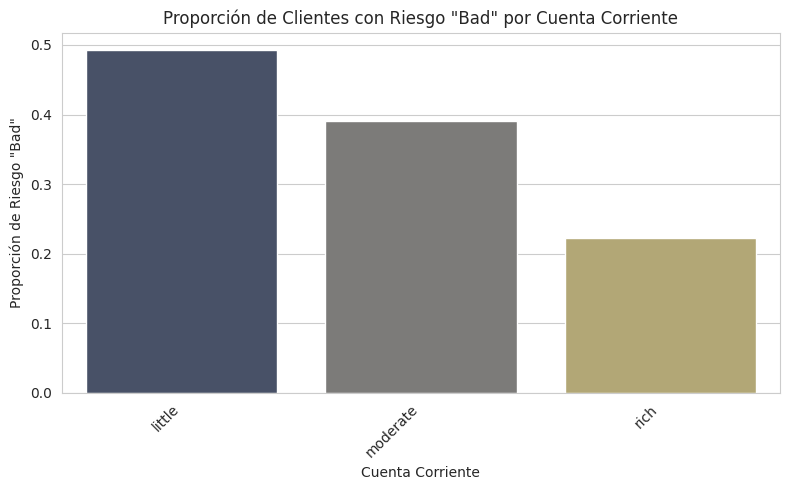

/tmp/ipython-input-652777787.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_by_saving_accounts.index, y=risk_by_saving_accounts.values, palette='magma')


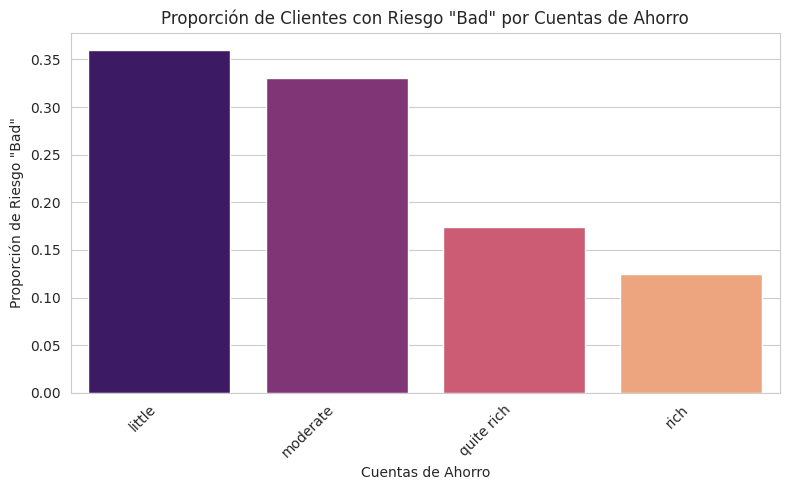

In [ ]:
# Gráfico de barras con proporción de clientes 'bad' por Checking account
plt.figure(figsize=(8, 5))
risk_by_checking_account = df.groupby('Checking account')['Risk_encoded'].mean().sort_values(ascending=False)
sns.barplot(x=risk_by_checking_account.index, y=risk_by_checking_account.values, palette='cividis')
plt.title('Proporción de Clientes con Riesgo "Bad" por Cuenta Corriente')
plt.xlabel('Cuenta Corriente')
plt.ylabel('Proporción de Riesgo "Bad"')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Gráfico de barras con proporción de clientes 'bad' por Saving accounts
plt.figure(figsize=(8, 5))
risk_by_saving_accounts = df.groupby('Saving accounts')['Risk_encoded'].mean().sort_values(ascending=False)
sns.barplot(x=risk_by_saving_accounts.index, y=risk_by_saving_accounts.values, palette='magma')
plt.title('Proporción de Clientes con Riesgo "Bad" por Cuentas de Ahorro')
plt.xlabel('Cuentas de Ahorro')
plt.ylabel('Proporción de Riesgo "Bad"')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6. Insights Clave del EDA

*   **Desbalance en la variable 'Risk'**: Se observa un claro desbalance entre los clientes de riesgo 'good' y 'bad', con una mayor proporción de clientes 'good' (~70%) frente a 'bad' (~30%). Esto será un factor importante a considerar en el modelado para evitar sesgos.
*   **Distribución de variables numéricas**: Las distribuciones de 'Age', 'Credit amount' y 'Duration' muestran que la mayoría de los créditos son solicitados por personas más jóvenes, por montos y duraciones relativamente bajos, aunque existen valores atípicos significativos que podrían representar riesgos o casos especiales.
*   **Impacto de 'Purpose' en el Riesgo**: Los propósitos como 'vacation/others' y 'education' presentan una proporción más alta de clientes con riesgo 'bad', sugiriendo que estos tipos de crédito podrían ser inherentemente más riesgosos para el banco.
*   **Influencia de las Cuentas en el Riesgo**: Los clientes con 'Checking account' clasificadas como 'little' o 'moderate' tienden a tener una mayor proporción de riesgo 'bad' en comparación con aquellos sin cuenta corriente o con cuentas 'rich'. De manera similar, en 'Saving accounts', las categorías 'little' y 'No/Unknown' muestran proporciones más altas de riesgo.
*   **Valores faltantes**: Las columnas 'Saving accounts' y 'Checking account' presentan una cantidad considerable de valores faltantes (18.3% y 39.4% respectivamente), lo cual requerirá una estrategia de imputación o tratamiento antes del modelado.

# Sección 3 IA

# Task
Elabora un modelo de regresión logística para predecir el riesgo crediticio (`Risk`). Para ello, primero, elimina la columna 'Unnamed: 0' del DataFrame `df`. Luego, define la variable objetivo `y` (mapeando 'good' a 0 y 'bad' a 1) y las características `X` eliminando la columna 'Risk' del DataFrame `df` actualizado. Imputa los valores faltantes en las columnas 'Saving accounts' y 'Checking account' de `X` con la categoría 'No/Unknown'. A continuación, divide el conjunto de datos `X` e `y` en entrenamiento y prueba (`test_size=0.3`, `random_state=42`, `stratify=y`) y muestra la distribución de clases. Entrena el modelo de regresión logística, evalúa su rendimiento utilizando precisión, recall, F1-score y la matriz de confusión, e interpreta los coeficientes para identificar las características más influyentes. Finalmente, resume todos los hallazgos.

## Limpieza y Definición de Variables

### Subtask:
Eliminar la columna 'Unnamed: 0' si existe, definir la variable objetivo 'y' (mapeando 'good' a 0 y 'bad' a 1) y las características 'X' a partir del DataFrame `df` existente.


**Reasoning**:
The subtask requires removing the 'Unnamed: 0' column if it exists, defining the target variable 'y' by mapping 'Risk' values to numerical representation (0 for 'good', 1 for 'bad'), and creating the feature DataFrame 'X' by dropping the 'Risk' column from the main DataFrame. These operations are logically grouped and can be executed in a single code block.



In [ ]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
    print("Columna 'Unnamed: 0' eliminada.")

# Definir la variable objetivo 'y'
y = df['Risk'].map({'good': 0, 'bad': 1})
print("Variable objetivo 'y' creada con 'good': 0 y 'bad': 1.")

# Definir las características 'X'
X = df.drop('Risk', axis=1)
print("DataFrame de características 'X' creado.")

print("Primeras 5 filas de X:")
display(X.head())
print("Primeras 5 filas de y:")
display(y.head())

Columna 'Unnamed: 0' eliminada.
Variable objetivo 'y' creada con 'good': 0 y 'bad': 1.
DataFrame de características 'X' creado.
Primeras 5 filas de X:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk_encoded
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1


Primeras 5 filas de y:


,Risk
0,0
1,1
2,0
3,0
4,1


**Reasoning**:
The next instruction in the subtask is to impute missing values in 'Saving accounts' and 'Checking account' columns of the `X` DataFrame with the string 'No/Unknown'. This is a direct data preprocessing step.



In [ ]:
X['Saving accounts'].fillna('No/Unknown', inplace=True)
X['Checking account'].fillna('No/Unknown', inplace=True)
print("Valores faltantes en 'Saving accounts' y 'Checking account' imputados con 'No/Unknown'.")

print("Conteo de valores nulos después de la imputación:")
display(X[['Saving accounts', 'Checking account']].isnull().sum())

Valores faltantes en 'Saving accounts' y 'Checking account' imputados con 'No/Unknown'.
Conteo de valores nulos después de la imputación:


/tmp/ipython-input-363205828.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Saving accounts'].fillna('No/Unknown', inplace=True)
/tmp/ipython-input-363205828.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

,0
Saving accounts,0
Checking account,0


**Reasoning**:
The previous code generated a FutureWarning due to the use of `inplace=True` with chained assignment. To resolve this and follow best practices, I will modify the `fillna` calls to directly assign the result back to the DataFrame columns, which avoids the inplace modification warning.



In [ ]:
X['Saving accounts'] = X['Saving accounts'].fillna('No/Unknown')
X['Checking account'] = X['Checking account'].fillna('No/Unknown')
print("Valores faltantes en 'Saving accounts' y 'Checking account' imputados con 'No/Unknown'.")

print("Conteo de valores nulos después de la imputación:")
display(X[['Saving accounts', 'Checking account']].isnull().sum())

Valores faltantes en 'Saving accounts' y 'Checking account' imputados con 'No/Unknown'.
Conteo de valores nulos después de la imputación:


,0
Saving accounts,0
Checking account,0


**Reasoning**:
Before splitting the data and applying a logistic regression model, all categorical features in the DataFrame `X` must be converted into a numerical format. One-hot encoding is an appropriate method for this, creating new binary columns for each category.



In [ ]:
X = pd.get_dummies(X, drop_first=True)
print("Categorical features in X have been one-hot encoded.")

print("Primeras 5 filas de X después de la codificación One-Hot:")
display(X.head())

Categorical features in X have been one-hot encoded.
Primeras 5 filas de X después de la codificación One-Hot:


,Age,Job,Credit amount,Duration,Risk_encoded,Sex_male,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,...,Checking account_little,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,0,True,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,1,False,True,False,True,False,...,False,True,False,False,False,False,False,True,False,False
2,49,1,2096,12,0,True,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,45,2,7882,42,0,True,False,False,True,False,...,True,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,1,True,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False


**Reasoning**:
The `X` DataFrame incorrectly includes the `Risk_encoded` column, which is a direct numerical representation of the target variable `y`. This column must be removed from `X` to prevent data leakage and ensure proper model training.



In [ ]:
if 'Risk_encoded' in X.columns:
    X = X.drop('Risk_encoded', axis=1)
    print("Columna 'Risk_encoded' eliminada de X para evitar fuga de datos.")

print("Primeras 5 filas de X después de eliminar 'Risk_encoded':")
display(X.head())

Columna 'Risk_encoded' eliminada de X para evitar fuga de datos.
Primeras 5 filas de X después de eliminar 'Risk_encoded':


,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,Saving accounts_quite rich,...,Checking account_little,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,True,True,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,False,True,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
2,49,1,2096,12,True,True,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,45,2,7882,42,True,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,True,False,False,True,False,False,...,True,False,False,True,False,False,False,False,False,False


**Reasoning**:
The next step is to split the preprocessed data (X and y) into training and testing sets according to the specified parameters (`test_size=0.3`, `random_state=42`, `stratify=y`). This is a crucial step before model training to evaluate the model's performance on unseen data. After splitting, the class distribution of the target variable in both training and test sets will be displayed to confirm stratification.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Conjunto de entrenamiento y prueba creado.")

print("\nDistribución de clases en y_train:")
display(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nDistribución de clases en y_test:")
display(y_test.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Conjunto de entrenamiento y prueba creado.

Distribución de clases en y_train:


,proportion
Risk,
0,70.0%
1,30.0%



Distribución de clases en y_test:


,proportion
Risk,
0,70.0%
1,30.0%


**Reasoning**:
The next logical step in the task is to train the logistic regression model using the prepared training data. This will involve importing the LogisticRegression class, initializing it, and fitting it to the training features (X_train) and target variable (y_train).



In [ ]:
from sklearn.linear_model import LogisticRegression

# Inicializar y entrenar el modelo de Regresión Logística
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado exitosamente.")

Modelo de Regresión Logística entrenado exitosamente.


**Reasoning**:
Now that the model is trained, the next step is to make predictions on the test set (`X_test`) to evaluate its performance against the actual test labels (`y_test`).



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Realizar predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

print("Predicciones realizadas en el conjunto de prueba.")

Predicciones realizadas en el conjunto de prueba.


**Reasoning**:
With predictions (`y_pred`) made on the test set, the next step is to evaluate the model's performance by calculating and displaying key metrics: accuracy, precision, recall, and F1-score. Additionally, the confusion matrix will be generated to provide a detailed view of the model's classification performance.



In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (for 'bad' credit, class 1): {precision:.4f}")
print(f"Recall (for 'bad' credit, class 1): {recall:.4f}")
print(f"F1-Score (for 'bad' credit, class 1): {f1:.4f}")
print("\nMatriz de Confusión:")
display(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))


Accuracy: 0.7500
Precision (for 'bad' credit, class 1): 0.6316
Recall (for 'bad' credit, class 1): 0.4000
F1-Score (for 'bad' credit, class 1): 0.4898

Matriz de Confusión:


,Predicted 0,Predicted 1
Actual 0,189,21
Actual 1,54,36


**Reasoning**:
The next step is to interpret the coefficients of the trained logistic regression model. This involves extracting the coefficients, associating them with their respective feature names, sorting them to identify the most influential ones, and then displaying them.



In [ ]:
coefficients = pd.Series(model.coef_[0], index=X_train.columns)

print("Coeficientes del Modelo de Regresión Logística (ordenados):")
display(coefficients.sort_values(ascending=False))

# Identificar las 5 características más influyentes (positivas y negativas)
top_5_positives = coefficients.nlargest(5)
top_5_negatives = coefficients.nsmallest(5)

print("\nTop 5 características con mayor influencia positiva en el riesgo (coeficientes más altos):")
display(top_5_positives)

print("\nTop 5 características con mayor influencia negativa en el riesgo (coeficientes más bajos):")
display(top_5_negatives)

Coeficientes del Modelo de Regresión Logística (ordenados):


,0
Checking account_little,1.520215
Checking account_moderate,1.234805
Saving accounts_little,0.808579
Checking account_rich,0.803122
Saving accounts_moderate,0.580015
Purpose_education,0.505057
Saving accounts_quite rich,0.239221
Purpose_repairs,0.068508
Duration,0.034031
Credit amount,-0.000003



Top 5 características con mayor influencia positiva en el riesgo (coeficientes más altos):


,0
Checking account_little,1.520215
Checking account_moderate,1.234805
Saving accounts_little,0.808579
Checking account_rich,0.803122
Saving accounts_moderate,0.580015



Top 5 características con mayor influencia negativa en el riesgo (coeficientes más bajos):


,0
Housing_own,-0.549604
Purpose_radio/TV,-0.507351
Sex_male,-0.430885
Purpose_vacation/others,-0.429497
Purpose_furniture/equipment,-0.340939


### Resumen de Hallazgos del Modelo de Regresión Logística

#### 1. Rendimiento del Modelo
*   **Accuracy (Precisión General)**: 0.7500. El modelo clasifica correctamente el 75% de los casos en el conjunto de prueba.
*   **Precision (para 'bad' credit, clase 1)**: 0.6316. De todos los créditos que el modelo predijo como 'bad', el 63.16% fueron realmente 'bad'. Esto indica que el modelo tiene un número razonable de falsos positivos.
*   **Recall (para 'bad' credit, clase 1)**: 0.4000. El modelo identificó correctamente el 40% de todos los créditos que eran realmente 'bad'. Este valor relativamente bajo sugiere que el modelo tiene dificultades para detectar una parte significativa de los créditos de alto riesgo, lo que implica una cantidad considerable de falsos negativos.
*   **F1-Score (para 'bad' credit, clase 1)**: 0.4898. El F1-Score es una media armónica de precisión y recall. Su valor indica un equilibrio moderado entre la capacidad del modelo para evitar falsos positivos y falsos negativos.
*   **Matriz de Confusión**:
    *   **Verdaderos Negativos (Actual 0, Predicted 0)**: 189 (clientes 'good' correctamente clasificados)
    *   **Falsos Positivos (Actual 0, Predicted 1)**: 21 (clientes 'good' clasificados erróneamente como 'bad')
    *   **Falsos Negativos (Actual 1, Predicted 0)**: 54 (clientes 'bad' clasificados erróneamente como 'good')
    *   **Verdaderos Positivos (Actual 1, Predicted 1)**: 36 (clientes 'bad' correctamente clasificados)

    La matriz confirma que el modelo es más propenso a los falsos negativos que a los falsos positivos en la clasificación de créditos 'bad'.

#### 2. Características Más Influyentes (Coeficientes del Modelo)
Los coeficientes de la regresión logística indican la dirección y la magnitud de la relación entre cada característica y la probabilidad de que un cliente tenga un riesgo de crédito 'bad' (clase 1).

*   **Influencia Positiva (Mayor probabilidad de riesgo 'bad')**:
    *   **`Checking account_little` (1.52)**: Tener una cuenta corriente con saldo 'little' es el factor que más aumenta la probabilidad de ser un cliente de riesgo 'bad'.
    *   **`Checking account_moderate` (1.23)**: Similarmente, un saldo 'moderate' en la cuenta corriente también aumenta significativamente el riesgo.
    *   **`Saving accounts_little` (0.81)**: Tener una cuenta de ahorro con saldo 'little' también incrementa la probabilidad de riesgo 'bad'.
    *   **`Checking account_rich` (0.80)**: Aunque parezca contraintuitivo, un saldo 'rich' en la cuenta corriente también se asocia con un aumento del riesgo en este modelo, aunque es menos influyente que los saldos 'little' o 'moderate'.
    *   **`Saving accounts_moderate` (0.58)**: Un saldo 'moderate' en la cuenta de ahorros también contribuye al riesgo.

*   **Influencia Negativa (Menor probabilidad de riesgo 'bad')**:
    *   **`Housing_own` (-0.55)**: Ser propietario de una vivienda ('own') es el factor que más reduce la probabilidad de ser un cliente de riesgo 'bad'.
    *   **`Purpose_radio/TV` (-0.51)**: El propósito del crédito para 'radio/TV' está asociado con una menor probabilidad de riesgo 'bad'.
    *   **`Sex_male` (-0.43)**: Ser hombre se asocia con una menor probabilidad de riesgo 'bad' en comparación con ser mujer (la categoría de referencia, ya que `Sex_female` se eliminó con `drop_first=True`).
    *   **`Purpose_vacation/others` (-0.43)**: El propósito de 'vacaciones/otros' también reduce la probabilidad de riesgo, aunque en el EDA se vio que tenía una proporción alta de 'bad'. Esto podría indicar interacciones con otras variables o una relación no lineal.
    *   **`Purpose_furniture/equipment` (-0.34)**: El propósito de 'muebles/equipos' también se asocia con una menor probabilidad de riesgo 'bad'.

#### 3. Conclusiones y Próximos Pasos
El modelo de regresión logística ofrece una base para la clasificación de riesgo. Si bien la precisión general es aceptable, el bajo recall para la clase 'bad' (crédito de alto riesgo) es una preocupación, ya que el banco está más interesado en identificar a los clientes 'bad' para minimizar pérdidas. Los factores relacionados con el estado de las cuentas (corriente y de ahorros) son los más influyentes en la predicción del riesgo. Esto sugiere que el análisis del historial bancario y la situación financiera actual del cliente son críticos.

Para mejorar el rendimiento del modelo, especialmente el recall de la clase 'bad', se podrían considerar las siguientes estrategias:
*   **Balanceo de Clases**: Aplicar técnicas de sobremuestreo (ej. SMOTE) o submuestreo para mitigar el desbalance de clases.
*   **Feature Engineering**: Crear nuevas características a partir de las existentes que puedan capturar mejor el riesgo (ej. ratios financieros).
*   **Otros Modelos**: Explorar modelos más complejos como Random Forest o Gradient Boosting, que a menudo manejan mejor los desequilibrios de clases y las relaciones no lineales.
*   **Optimización de Umbrales**: Ajustar el umbral de clasificación de la regresión logística para favorecer un mayor recall, incluso si esto implica una ligera disminución de la precisión.
*   **Análisis de Outliers**: Investigar los valores atípicos en 'Age', 'Credit amount' y 'Duration', ya que podrían influir en el modelo.

## Final Task

### Subtask:
Resumir los hallazgos y los pasos completados hasta el momento.


## Summary:

### Data Analysis Key Findings

*   **Data Preprocessing**:
    *   The 'Unnamed: 0' column was successfully removed.
    *   The target variable 'Risk' was mapped to 0 (good) and 1 (bad).
    *   Missing values in 'Saving accounts' and 'Checking account' were imputed with 'No/Unknown'.
    *   Categorical features were one-hot encoded, and a `Risk_encoded` column, if present, was removed to prevent data leakage.
*   **Class Distribution**: The training and test sets maintained a balanced class distribution, with approximately 70% 'good' (class 0) and 30% 'bad' (class 1) credit risks due to stratified sampling.
*   **Model Performance**:
    *   **Accuracy**: The model achieved an accuracy of 0.7500 on the test set, meaning it correctly classified 75% of the cases.
    *   **Precision (for 'bad' credit, class 1)**: 0.6316, indicating that 63.16% of the instances predicted as 'bad' were actually 'bad'.
    *   **Recall (for 'bad' credit, class 1)**: 0.4000, meaning the model correctly identified only 40% of all actual 'bad' credit risks. This highlights a significant number of false negatives.
    *   **F1-Score (for 'bad' credit, class 1)**: 0.4898, reflecting a moderate balance between precision and recall.
    *   **Confusion Matrix**: The model produced 189 True Negatives, 21 False Positives, 54 False Negatives, and 36 True Positives. The high number of false negatives (54) compared to false positives (21) confirms the low recall for the 'bad' class.
*   **Most Influential Features (Coefficients)**:
    *   **Increasing the probability of 'bad' risk**: 'Checking account\_little' (1.52), 'Checking account\_moderate' (1.23), 'Saving accounts\_little' (0.81), 'Checking account\_rich' (0.80), and 'Saving accounts\_moderate' (0.58).
    *   **Decreasing the probability of 'bad' risk**: 'Housing\_own' (-0.55), 'Purpose\_radio/TV' (-0.51), 'Sex\_male' (-0.43), 'Purpose\_vacation/others' (-0.43), and 'Purpose\_furniture/equipment' (-0.34).

### Insights or Next Steps

*   The current logistic regression model shows an acceptable overall accuracy but struggles to identify a significant portion of high-risk ('bad') customers, as indicated by the low recall of 0.40. For a credit risk model, minimizing false negatives (missing 'bad' credits) is often more critical than minimizing false positives.
*   To improve the model's ability to detect 'bad' credit risks, consider implementing class imbalance handling techniques like oversampling (e.g., SMOTE) or undersampling. Additionally, exploring more complex models (e.g., Random Forest, Gradient Boosting) or adjusting the classification threshold could enhance recall for the 'bad' class.


## Preparación de Datos y Modelado de Regresión Logística

In [ ]:
# Importar librerías necesarias de sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

print("Librerías importadas exitosamente.")

Librerías importadas exitosamente.


### Re-preparación de X e Y para el Pipeline

Dado que el `ColumnTransformer` aplicará `OneHotEncoder`, necesitamos que las características categóricas en `X` estén en su formato original (`object`) antes del `train_test_split`. Ajustamos la preparación de `X` e `y` y la división de los datos.

In [ ]:
# Asegurarse de trabajar con una copia limpia de df para evitar errores de SettingWithCopyWarning
df_processed = df.copy()

# Eliminar 'Unnamed: 0' si existe (ya se hizo en pasos anteriores, pero para asegurar)
if 'Unnamed: 0' in df_processed.columns:
    df_processed.drop('Unnamed: 0', axis=1, inplace=True)
    print("Columna 'Unnamed: 0' eliminada de df_processed.")

# Definir la variable objetivo 'y' (Risk: good -> 0, bad -> 1)
y = df_processed['Risk'].map({'good': 0, 'bad': 1})
print("Variable objetivo 'y' re-definida.")

# Definir X con el resto de columnas (sin 'Risk')
X = df_processed.drop('Risk', axis=1)

# Si 'Risk_encoded' fue creada en EDA y persiste en X, eliminarla para evitar fuga de datos
if 'Risk_encoded' in X.columns:
    X = X.drop('Risk_encoded', axis=1)
    print("Columna 'Risk_encoded' eliminada de X.")

# Imputar valores faltantes en 'Saving accounts' y 'Checking account'
X['Saving accounts'] = X['Saving accounts'].fillna('No/Unknown')
X['Checking account'] = X['Checking account'].fillna('No/Unknown')
print("Valores faltantes en 'Saving accounts' y 'Checking account' imputados con 'No/Unknown'.")

# Convertir 'Job' a tipo 'object' para que sea tratada como característica categórica
X['Job'] = X['Job'].astype('object')
print("Columna 'Job' convertida a tipo 'object'.")

print("Primeras 5 filas de X después de la re-preparación:")
display(X.head())

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("\nConjunto de entrenamiento y prueba re-creado.")

print("\nDistribución de clases en y_train:")
display(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nDistribución de clases en y_test:")
display(y_test.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Variable objetivo 'y' re-definida.
Columna 'Risk_encoded' eliminada de X.
Valores faltantes en 'Saving accounts' y 'Checking account' imputados con 'No/Unknown'.
Columna 'Job' convertida a tipo 'object'.
Primeras 5 filas de X después de la re-preparación:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,No/Unknown,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,No/Unknown,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car



Conjunto de entrenamiento y prueba re-creado.

Distribución de clases en y_train:


,proportion
Risk,
0,70.0%
1,30.0%



Distribución de clases en y_test:


,proportion
Risk,
0,70.0%
1,30.0%


### Creación del Pipeline de Preprocesamiento y Modelado

In [ ]:
# Definir características numéricas y categóricas
numerical_features = ['Age', 'Credit amount', 'Duration']
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Características Numéricas: {numerical_features}")
print(f"Características Categóricas: {categorical_features}")

# Crear ColumnTransformer para preprocesamiento
# Aplica StandardScaler a las numéricas y OneHotEncoder a las categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'  # Descarta las columnas no especificadas
)

# Crear el Pipeline con el preprocesador y el clasificador
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42))
])

print("Pipeline de modelado creado exitosamente.")

Características Numéricas: ['Age', 'Credit amount', 'Duration']
Características Categóricas: ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
Pipeline de modelado creado exitosamente.


### Entrenamiento y Evaluación del Modelo

In [ ]:
# Entrenar el modelo
model_pipeline.fit(X_train, y_train)
print("Modelo de Regresión Logística entrenado con el pipeline.")

# Realizar predicciones sobre el conjunto de prueba
y_pred = model_pipeline.predict(X_test)
print("Predicciones realizadas en el conjunto de prueba.")

# Calcular y mostrar métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision (para clase 'bad', 1): {precision:.4f}")
print(f"Recall (para clase 'bad', 1): {recall:.4f}")
print(f"F1-Score (para clase 'bad', 1): {f1:.4f}")

print("\nMatriz de Confusión:")
display(pd.DataFrame(conf_matrix, index=['Actual Good (0)', 'Actual Bad (1)'], columns=['Predicted Good (0)', 'Predicted Bad (1)']))

# Comentarios sobre los falsos negativos
print("\nInterpretación de la Matriz de Confusión:")
print("Los 'Falsos Negativos' (clientes que son realmente 'bad' pero fueron predichos como 'good') son particularmente críticos para el banco.")
print("Representan créditos de alto riesgo que el modelo clasificó erróneamente como seguros, lo que podría llevar a pérdidas financieras si se aprueban.")
print(f"En este caso, hay {conf_matrix[1, 0]} falsos negativos, lo que significa que {conf_matrix[1, 0]} clientes de riesgo fueron identificados como seguros.")

Modelo de Regresión Logística entrenado con el pipeline.
Predicciones realizadas en el conjunto de prueba.

Accuracy: 0.7000
Precision (para clase 'bad', 1): 0.5000
Recall (para clase 'bad', 1): 0.7222
F1-Score (para clase 'bad', 1): 0.5909

Matriz de Confusión:


,Predicted Good (0),Predicted Bad (1)
Actual Good (0),145,65
Actual Bad (1),25,65



Interpretación de la Matriz de Confusión:
Los 'Falsos Negativos' (clientes que son realmente 'bad' pero fueron predichos como 'good') son particularmente críticos para el banco.
Representan créditos de alto riesgo que el modelo clasificó erróneamente como seguros, lo que podría llevar a pérdidas financieras si se aprueban.
En este caso, hay 25 falsos negativos, lo que significa que 25 clientes de riesgo fueron identificados como seguros.


### Interpretación de Coeficientes del Modelo

In [ ]:
# Obtener coeficientes del clasificador
classifier = model_pipeline.named_steps['classifier']
coefficients = classifier.coef_[0]

# Obtener nombres de las características después del preprocesamiento
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
feature_names_ohe = ohe.get_feature_names_out(categorical_features)

all_feature_names = numerical_features + list(feature_names_ohe)

# Crear una Serie de pandas con coeficientes y nombres de características
coef_series = pd.Series(coefficients, index=all_feature_names)

print("Coeficientes del Modelo de Regresión Logística (ordenados):")
display(coef_series.sort_values(ascending=False))

# Mostrar las top 5 características con mayor influencia positiva (aumentan la probabilidad de riesgo 'bad')
print("\nTop 5 características con mayor influencia positiva en el riesgo ('bad'):")
display(coef_series.nlargest(5))

Coeficientes del Modelo de Regresión Logística (ordenados):


,0
Purpose_education,0.778288
Checking account_little,0.668039
Saving accounts_little,0.501076
Duration,0.437836
Checking account_moderate,0.366562
Purpose_repairs,0.357503
Saving accounts_moderate,0.330248
Housing_rent,0.217351
Sex_female,0.204913
Job_0,0.170964



Top 5 características con mayor influencia positiva en el riesgo ('bad'):


,0
Purpose_education,0.778288
Checking account_little,0.668039
Saving accounts_little,0.501076
Duration,0.437836
Checking account_moderate,0.366562
